## Exercise 14 — Collinearity

- **(a)** Generate the data and identify the true regression coefficients.
- **(b)** Compute the correlation between $X_1$ and $X_2$, visualize with a scatterplot.
- **(c)** Fit $Y$ on both $X_1$ and $X_2$. Can we reject $H_0: \beta_1 = 0$? And $H_0: \beta_2 = 0$?
- **(d)** Fit $Y$ on $X_1$ alone. Can we reject $H_0: \beta_1 = 0$?
- **(e)** Fit $Y$ on $X_2$ alone. Can we reject $H_0: \beta_1 = 0$?
- **(f)** Do (c)–(e) contradict each other? Explain.
- **(g)** Add a mismeasured outlier and re-fit all models. 
        Assess whether the new point is an outlier, a high-leverage point, or both.


In [1]:

import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

import statsmodels.api as sm

from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS ,
                        summarize ,
                        poly)

In [2]:
rng = np.random.default_rng (10)
x1 = rng.uniform (0, 1, size =100)
x2 = 0.5 * x1 + rng.normal(size =100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size =100)

Text(0, 0.5, 'x2')

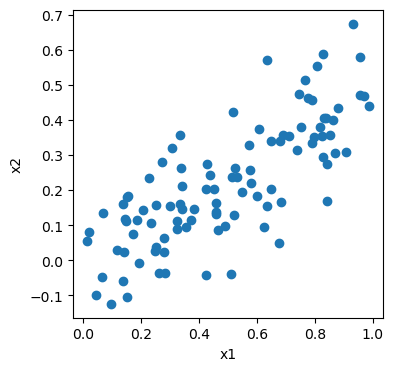

In [3]:
# correlation between x1 and x2
ax = subplots(figsize=(4,4))[1]
ax.scatter(x1,x2)
ax.set_xlabel('x1')
ax.set_ylabel('x2')


### Using both x1 and x2

In [4]:
df = pd.DataFrame({'x1':x1, 'x2':x2, 'y':y})
X = MS(['x1','x2']).fit_transform(df)
model1 = sm.OLS(y,X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,1.9579,0.190,10.319,0.000
x1,1.6154,0.527,3.065,0.003
x2,0.9428,0.831,1.134,0.259


* we can reject the null hypothesis $H_0:\beta_1=0$
* we can't reject the null hypothesis $H_0:\beta_2=0$

But form the graph we have assessed that $x_1$ and $x_2$ show a dependence. 

### Using just x1

In [6]:
df2 = pd.DataFrame({'x1':x1,'y':y})
X2 = MS(['x1']).fit_transform(df2)
model2 = sm.OLS(y,X2)
results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
intercept,1.9371,0.189,10.242,0.0
x1,2.0771,0.335,6.196,0.0


The prediction for intercept and $\beta_{x_1}$ are more accurate, and we can reject $H_0:\beta_{x_1}=0$

### Using just X2

In [8]:
df3 = pd.DataFrame({'x2':x2,'y':y})
X3 = MS(['x2']).fit_transform(df3)
model3 = sm.OLS(y,X3)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,2.3239,0.154,15.124,0.0
x2,2.9103,0.550,5.291,0.0


We can't reject $H_0:\beta_{x_2}=0$. 

The results seam to contradict each other, but a plausible reason is the collinearity between x1 and x2

### Test

Suppose we obtain one additional observation, which was unfortunately mismeasured. We use the function np.concatenate() to add this additional observation to each of x1, x2 and y.

In [12]:
x1 = np. concatenate ([x1 , [0.1]])
x2 = np. concatenate ([x2 , [0.8]])
y = np. concatenate ([y, [6]])


In [13]:
df = pd.DataFrame({'x1':x1, 'x2':x2, 'y':y})
X = MS(['x1','x2']).fit_transform(df)
model1 = sm.OLS(y,X)
results1 = model1.fit()
print(summarize(results1))


df2 = pd.DataFrame({'x1':x1,'y':y})
X2 = MS(['x1']).fit_transform(df2)
model2 = sm.OLS(y,X2)
results2 = model2.fit()
print(summarize(results2))


df3 = pd.DataFrame({'x2':x2,'y':y})
X3 = MS(['x2']).fit_transform(df3)
model3 = sm.OLS(y,X3)
results3 = model3.fit()
print(summarize(results3))

             coef  std err       t  P>|t|
intercept  2.1417    0.193  11.115  0.000
x1         0.2744    0.403   0.681  0.497
x2         3.2849    0.567   5.791  0.000
             coef  std err       t  P>|t|
intercept  2.3242    0.219  10.633    0.0
x1         1.5085    0.393   3.838    0.0
             coef  std err       t  P>|t|
intercept  2.2259    0.148  15.091    0.0
x2         3.4893    0.480   7.268    0.0


* Before outlier (model with both $X_1$, $X_2$): $\beta_{x_1}$ significant (p=0.003), $\beta_{x_2}$ not significant (p=0.259)
* After outlier (model with both $X_1$, $X_2$): $\beta_{x_1}$ not significant (p=0.497), $\beta_{x_2}$ significant (p=0.000)

One bad-observation can determine which variable appears to be relevant and which not. 

Text(0.20507447198272058, 1.4136473002519387, '101')

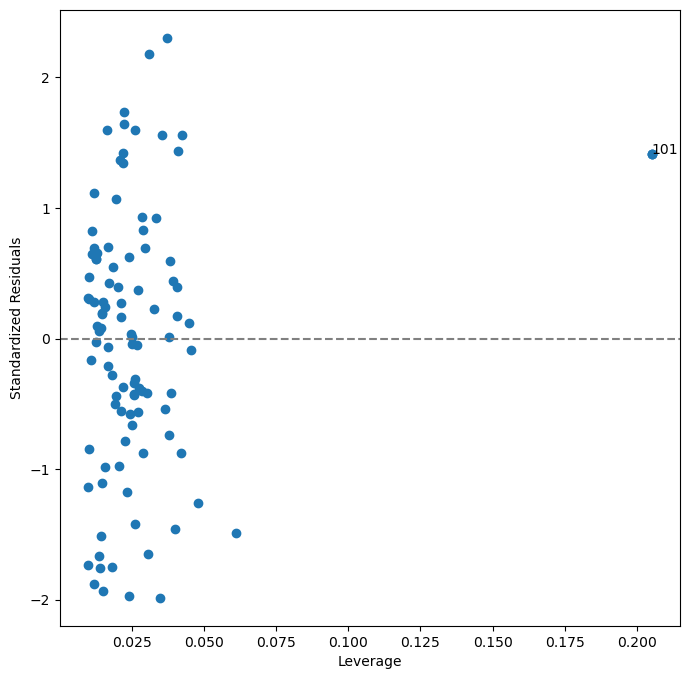

In [16]:

infl = results1.get_influence()
leverage = infl.hat_matrix_diag
std_residual = infl.resid_studentized_internal

fig, ax = subplots(figsize=(8,8))
ax.scatter(leverage,std_residual)
ax.set_xlabel('Leverage')
ax.set_ylabel('Standardized Residuals')
ax.axhline(y=0, ls='--', c='grey')

ax.annotate('101',(leverage[-1],std_residual[-1]))

This graph shows that the added point has high residual and high leverage, this combinations of influence values is dangerous fot the fitting procedure.

Standardized Residual are necessary because normal residuals are misleading for high-leverage points, since they pulls the regression line toward themselves producing shrunk residuals. A standardized residual is the residual divided by it own standard deviation. 

$$r_i = \frac{e_i}{\hat{\sigma}({e_i})} = \frac{e_i}{\hat{\sigma}\sqrt{1-h_{ii}}} $$

